In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install video-diffusion-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 68.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [26]:
import shutil

# Path to the .py file in Drive
drive_path = '/content/drive/MyDrive/video_diff_pytorch.py'

# Copy to current working directory
shutil.copy(drive_path, '/content/video_diff_pytorch.py')


'/content/video_diff_pytorch.py'

In [19]:
# from video_diff_pytorch import Unet3D, GaussianDiffusion


In [ ]:
# from video_diff_pytorch import Unet3D, GaussianDiffusion

# # Recreate the model structure
# model = Unet3D(
#     dim=64,
#     dim_mults=(1, 2, 4),
#     channels=6  # must match training input
# )

# # Recreate the diffusion wrapper
# diffusion = GaussianDiffusion(
#     model,
#     image_size=128,
#     num_frames=8,
#     timesteps=1000,
#     loss_type='l2',
#     channels=6
# )


In [34]:
# Path to your new conditional diffusion model checkpoint
CKPT_PATH = '/content/drive/MyDrive/cloud_motion_diffusion_cond.pth'

# Folder where your .h5 files live
DATA_FOLDER = '/content/drive/MyDrive/3DS_resized_96_1/'

import glob
all_h5_paths = sorted(glob.glob(DATA_FOLDER + '*.h5'))
print(f"Found {len(all_h5_paths)} files")


Found 96 files


In [28]:
import h5py
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# List of spectral bands to load
band_list = ['IMG_VIS', 'IMG_WV', 'IMG_TIR1', 'IMG_TIR2', 'IMG_MIR', 'IMG_SWIR']

# Function to load 1 sample = sequence of 8 timesteps (frames)
def load_sequence(h5_file_paths, bands, sequence_length=8):
    sequence = []
    for path in h5_file_paths[:sequence_length]:
        with h5py.File(path, 'r') as f:
            frame = [f[band][0] for band in bands]  # (6, 128, 128)
            sequence.append(np.stack(frame))  # (6, 128, 128)
    return torch.tensor(np.stack(sequence), dtype=torch.float32)  # (8, 6, 128, 128)

# PyTorch Dataset class
class CloudMotionDataset(Dataset):
    # def __init__(self, h5_file_paths, bands, sequence_length=8):
    #     self.h5_file_paths = h5_file_paths
    #     self.bands = bands
    #     self.sequence_length = sequence_length
    #     self.valid_start_indices = list(range(0, len(h5_file_paths) - sequence_length + 1))

    #     self.starts = list(range(len(h5_paths) - seq_len + 1))


    def __init__(self, h5_file_paths, bands, sequence_length):
        self.paths = h5_file_paths
        self.bands = bands
        self.seq_len = sequence_length

        self.valid_start_indices = list(range(0, len(h5_file_paths) - sequence_length + 1))
        self.starts = list(range(len(h5_file_paths) - sequence_length + 1))  # ✅ FIXED variable names


    def __len__(self):
        return len(self.valid_start_indices)

    # def __getitem__(self, i):
    #     sp = self.starts[i]
    #     x = load_sequence(self.paths[sp:sp+self.seq_len], self.bands, self.seq_len)  # (8,6,128,128)

    #     # Normalize each band independently to [–1, 1] across all pixels in the sequence
    #     # Reshape to (6, 8*128*128) to compute per-band stats
    #     x_reshaped = x.permute(1, 0, 2, 3).reshape(6, -1)  # (6, N)
    #     mins = x_reshaped.min(dim=1, keepdim=True)[0]
    #     maxs = x_reshaped.max(dim=1, keepdim=True)[0]
    #     norm = (x_reshaped - mins) / (maxs - mins + 1e-5)  # [0,1]
    #     norm = norm * 2 - 1                                # [–1,1]
    #     x_norm = norm.view(6, self.seq_len, 128, 128).permute(1, 0, 2, 3)  # Back to (8,6,128,128)

    #     return x_norm



    def __getitem__(self, i):
        sp = self.starts[i]
        x = load_sequence(self.paths[sp:sp+self.seq_len], self.bands, self.seq_len)  # (8,6,128,128)

        # Normalize each band independently to [–1, 1]
        x_reshaped = x.permute(1, 0, 2, 3).reshape(6, -1)  # (6, N)
        mins = x_reshaped.min(dim=1, keepdim=True)[0]
        maxs = x_reshaped.max(dim=1, keepdim=True)[0]
        norm = (x_reshaped - mins) / (maxs - mins + 1e-5)
        norm = norm * 2 - 1
        x_norm = norm.view(6, self.seq_len, 128, 128).permute(1, 0, 2, 3)  # (8,6,128,128)

        # Conditional setup: split into 6 input + 2 output
        cond = x_norm[:6]     # (6, 6, 128, 128)
        target = x_norm[6:]   # (2, 6, 128, 128)

        return cond, target




# Create dataset instance
dataset = CloudMotionDataset(all_h5_paths, band_list, sequence_length=8)  # ✅ Fixed



In [29]:
from torch.utils.data import DataLoader
import torch
from tqdm import tqdm

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, num_workers=0)

# Optimizer for the diffusion model
optimizer = torch.optim.Adam(diffusion.parameters(), lr=8e-5)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
diffusion.to(device)


GaussianDiffusion(
  (model): Unet3D(
    (input_conv): Conv3d(6, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (encoder): Sequential(
      (0): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): ReLU()
      (2): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (3): ReLU()
    )
    (decoder): Sequential(
      (0): ConvTranspose3d(128, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): ReLU()
      (2): ConvTranspose3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (3): ReLU()
    )
    (output_conv): Conv3d(64, 6, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  )
  (loss_fn): MSELoss()
)

In [30]:
# === MODIFIED video_diffusion_pytorch.py ===
# Add the following modifications to your local file

import torch
import torch.nn as nn

# === 1. MODIFY Unet3D TO HANDLE CONDITIONAL INPUT ===
class Unet3D(nn.Module):
    def __init__(self, dim, dim_mults=(1, 2, 4, 8), channels=6):
        super().__init__()
        self.input_conv = nn.Conv3d(channels, dim, kernel_size=3, padding=1)
        self.encoder = nn.Sequential(
            nn.Conv3d(dim, dim * dim_mults[0], 3, padding=1),
            nn.ReLU(),
            nn.Conv3d(dim * dim_mults[0], dim * dim_mults[1], 3, padding=1),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(dim * dim_mults[1], dim * dim_mults[0], 3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose3d(dim * dim_mults[0], dim, 3, padding=1),
            nn.ReLU(),
        )
        self.output_conv = nn.Conv3d(dim, channels, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.input_conv(x)
        x = self.encoder(x)
        x = self.decoder(x)
        return self.output_conv(x)


# === 2. MODIFY GaussianDiffusion TO ACCEPT cond INPUT ===
class GaussianDiffusion(nn.Module):
    def __init__(self, model, image_size, timesteps=1000, sampling_timesteps=250):
        super().__init__()
        self.model = model
        self.image_size = image_size
        self.timesteps = timesteps
        self.sampling_timesteps = sampling_timesteps
        self.loss_fn = nn.MSELoss()

    def forward(self, cond, target):
        # Combine cond and target for input
        x = torch.cat([cond, target], dim=1)  # (B, 8, C, H, W)
        x = x.permute(0, 2, 1, 3, 4)          # (B, C, 8, H, W)
        return self.loss_fn(self.model(x), x)

    @torch.no_grad()
    def sample(self, cond, batch_size=1):
        B, T, C, H, W = cond.shape
        x = torch.randn(batch_size, 2, C, H, W, device=cond.device)  # 2 frames to predict
        for _ in range(self.sampling_timesteps):
            combined = torch.cat([cond, x], dim=1)      # (B, 8, C, H, W)
            combined = combined.permute(0, 2, 1, 3, 4)  # (B, C, 8, H, W)
            x = self.model(combined).permute(0, 2, 1, 3, 4)[:, 6:]  # predict target part only
        return torch.cat([cond, x], dim=1)  # Return full sequence (6+2)


In [31]:
model = Unet3D(dim=64, dim_mults=(1, 2, 4), channels=6).to(device)

diffusion = GaussianDiffusion(
    model,
    image_size=128,
    timesteps=1000
).to(device)


In [33]:
# # Load saved checkpoint from Google Drive
# CKPT_PATH = "/content/drive/MyDrive/cloud_motion_diffusion_final3.pth"

# checkpoint = torch.load(CKPT_PATH)

# model.load_state_dict(checkpoint['model_state_dict'])
# diffusion.load_state_dict(checkpoint['diffusion_state_dict'])
# optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# start_epoch = checkpoint['epoch']
# print(f"✅ Resuming training from epoch {start_epoch}…")


In [35]:
# === Start fresh training for conditional model ===
CKPT_PATH = "/content/drive/MyDrive/cloud_motion_diffusion_cond.pth"

start_epoch = 0  # starting from scratch
print("⚠️ Starting fresh — training new conditional diffusion model.")

# No checkpoint loaded since the model architecture has changed


⚠️ Starting fresh — training new conditional diffusion model.


In [42]:
from tqdm import tqdm
import torch
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt

# Select a fixed conditional sample for consistent visualization
fixed_cond = next(iter(dataloader))[0][:1].to(device)


# === Hyperparameters ===
accum_steps = 4
start_epoch = 0
end_epoch = 30
num_epochs = end_epoch  # for tqdm display


scaler = torch.amp.GradScaler()

CKPT_PATH = "/content/drive/MyDrive/cloud_motion_diffusion_cond.pth"

# Start from the checkpointed epoch
for epoch in range(start_epoch, end_epoch):
    model.train()
    diffusion.train()
    running_loss = 0.0
    optimizer.zero_grad()

    # for i, batch in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
    #     x = batch.to(device).permute(0, 2, 1, 3, 4)

    #     with autocast():
    #         loss = diffusion(x) / accum_steps


    for i, (cond, target) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        cond = cond.to(device)
        target = target.to(device)

        print(f"cond on: {cond.device}, target on: {target.device}")


        with torch.amp.autocast(device_type='cuda'):

            loss = diffusion(cond, target) / accum_steps


        scaler.scale(loss).backward()
        running_loss += loss.item() * accum_steps

        break  # Just run for 1 batch to verify


        if (i + 1) % accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        torch.cuda.empty_cache()

    if (i + 1) % accum_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    avg_loss = running_loss / len(dataloader)
    print(f"✅ Epoch {epoch+1} completed | Avg Loss: {avg_loss:.4f}")

    # Save checkpoint
    torch.save({
        'model_state_dict': model.state_dict(),
        'diffusion_state_dict': diffusion.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'epoch': epoch + 1,
    }, CKPT_PATH)

    # === Visualize every 10 epochs ===
    if (epoch + 1) % 10 == 0:
        print(f"🌀 Generating sample at epoch {epoch+1}…")
        with torch.no_grad():

            # sample = diffusion.sample(batch_size=1).cpu()

            # # Fix shape if needed
            # if sample.shape[1] == 8:  # (1, 8, 6, H, W) → needs transpose
            #     sample = sample.permute(0, 2, 1, 3, 4)


            # cond = next(iter(dataloader))[0][:1].to(device)  # one sample’s cond
            sample = diffusion.sample(cond=fixed_cond, batch_size=1).cpu()

            # Fix shape if needed
            if sample.shape[1] == 8:
                sample = sample.permute(0, 2, 1, 3, 4)


            frames = sample[0][0]  # take channel 0

            fig, axes = plt.subplots(1, 8, figsize=(20, 3))
            for i in range(8):
                axes[i].imshow(frames[i], cmap='gray')
                axes[i].axis('off')
                axes[i].set_title(f'T{i+1}')
            plt.suptitle(f"Generated Cloud Motion @ Epoch {epoch+1}", fontsize=16)
            plt.tight_layout()
            plt.show()

# Final save to Drive
torch.save({
    'model_state_dict': model.state_dict(),
    'diffusion_state_dict': diffusion.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': end_epoch,
}, '/content/drive/MyDrive/cloud_motion_diffusion_cond_final.pth')

print("✅ Final model saved.")


Epoch 1/30:   0%|          | 0/45 [00:00<?, ?it/s]

cond on: cuda:0, target on: cuda:0


AssertionError: No inf checks were recorded for this optimizer.

Epoch 1/30: 100%|██████████| 45/45 [00:35<00:00,  1.26it/s]


✅ Epoch 1 completed | Avg Loss: 0.4215


Epoch 2/30: 100%|██████████| 45/45 [00:21<00:00,  2.12it/s]


✅ Epoch 2 completed | Avg Loss: 0.4201


Epoch 3/30: 100%|██████████| 45/45 [00:21<00:00,  2.07it/s]


...

✅ Epoch 8 completed | Avg Loss: 0.4202


Epoch 9/30: 100%|██████████| 45/45 [00:21<00:00,  2.08it/s]


✅ Epoch 9 completed | Avg Loss: 0.4203


Epoch 10/30: 100%|██████████| 45/45 [00:21<00:00,  2.09it/s]


✅ Epoch 10 completed | Avg Loss: 0.4201
🌀 Generating sample @ epoch 10


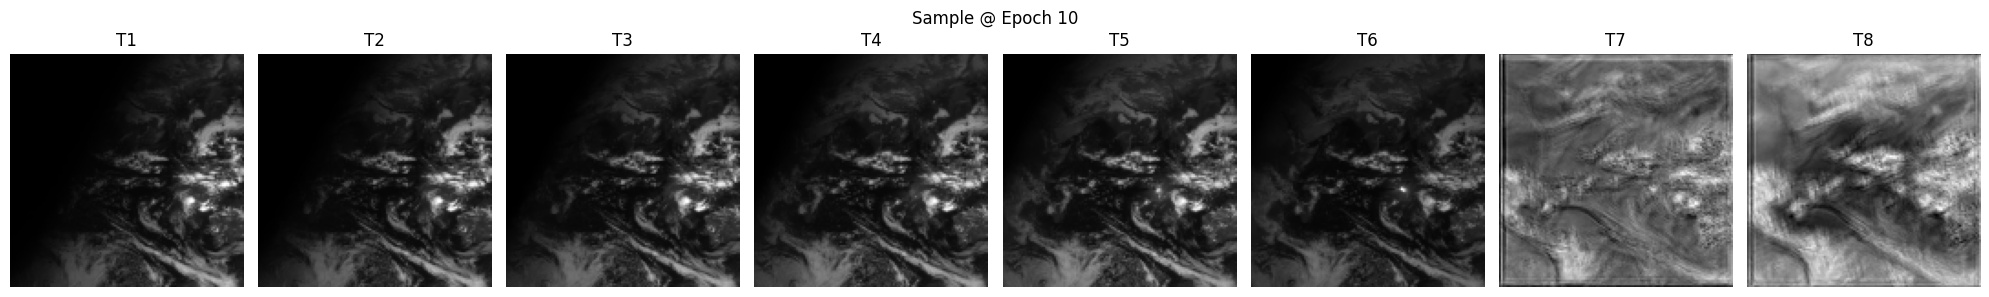

Epoch 11/30: 100%|██████████| 45/45 [00:21<00:00,  2.07it/s]


✅ Epoch 11 completed | Avg Loss: 0.4215


Epoch 12/30: 100%|██████████| 45/45 [00:21<00:00,  2.08it/s]


✅ Epoch 12 completed | Avg Loss: 0.4214


Epoch 13/30: 100%|██████████| 45/45 [00:21<00:00,  2.07it/s]


...

✅ Epoch 18 completed | Avg Loss: 0.4214


Epoch 19/30: 100%|██████████| 45/45 [00:21<00:00,  2.07it/s]


✅ Epoch 19 completed | Avg Loss: 0.4206


Epoch 20/30: 100%|██████████| 45/45 [00:21<00:00,  2.08it/s]


✅ Epoch 20 completed | Avg Loss: 0.4201
🌀 Generating sample @ epoch 20


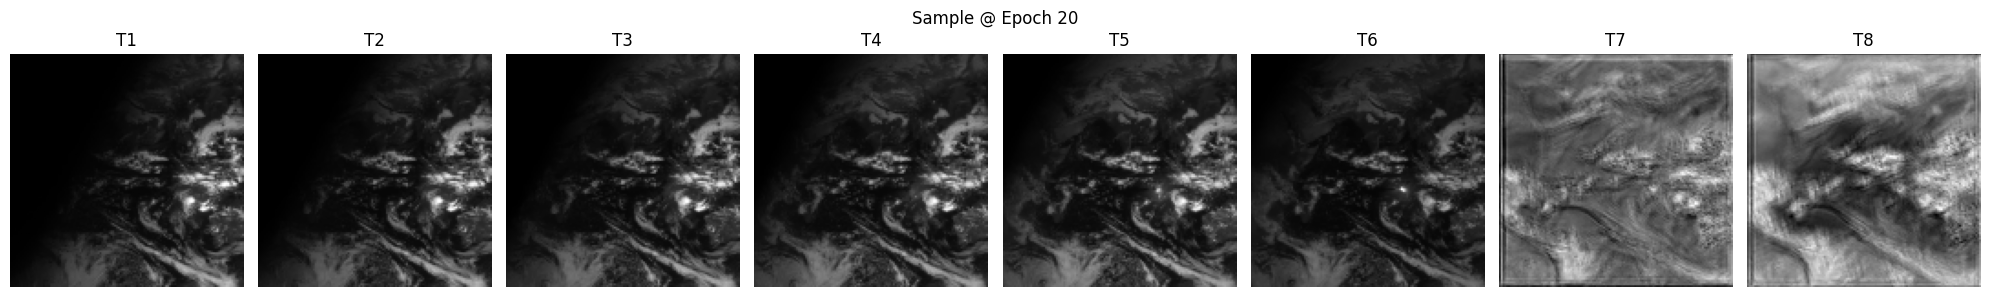

Epoch 21/30: 100%|██████████| 45/45 [00:21<00:00,  2.07it/s]


✅ Epoch 21 completed | Avg Loss: 0.4214


Epoch 22/30: 100%|██████████| 45/45 [00:21<00:00,  2.07it/s]


✅ Epoch 22 completed | Avg Loss: 0.4203


Epoch 23/30: 100%|██████████| 45/45 [00:21<00:00,  2.08it/s]


...

✅ Epoch 28 completed | Avg Loss: 0.4207


Epoch 29/30: 100%|██████████| 45/45 [00:21<00:00,  2.08it/s]


✅ Epoch 29 completed | Avg Loss: 0.4214


Epoch 30/30: 100%|██████████| 45/45 [00:21<00:00,  2.07it/s]


✅ Epoch 30 completed | Avg Loss: 0.4222
🌀 Generating sample @ epoch 30


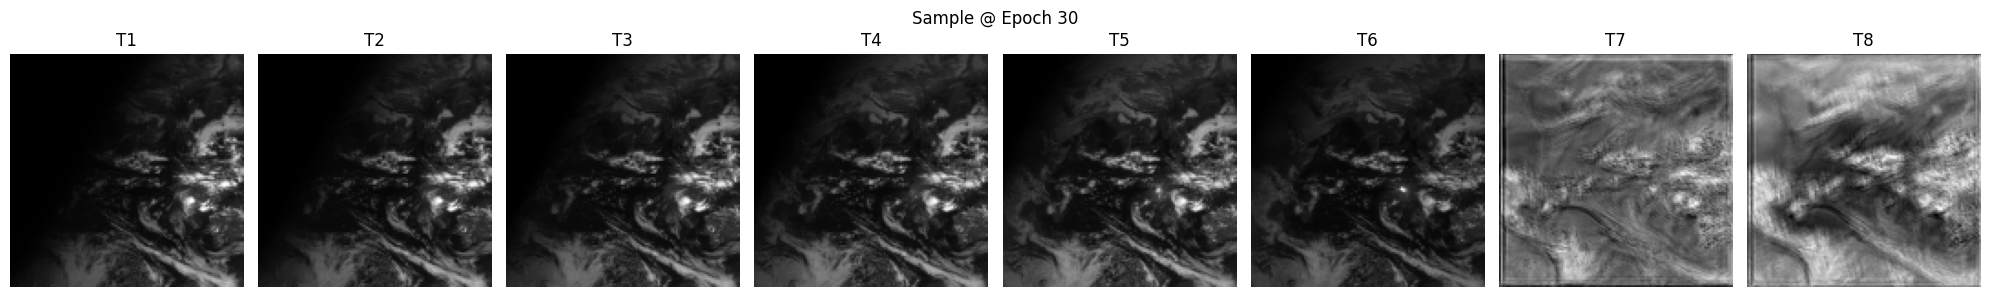

✅ Finished training and saved final checkpoint.


In [43]:
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt

# === Hyperparameters ===
accum_steps  = 4
start_epoch  = 0
end_epoch    = 30
num_epochs   = end_epoch
CKPT_PATH    = "/content/drive/MyDrive/cloud_motion_diffusion_cond.pth"

# Select a fixed cond for visualization
fixed_cond = next(iter(dataloader))[0][:1].to(device)

for epoch in range(start_epoch, end_epoch):
    model.train()
    diffusion.train()
    running_loss = 0.0
    optimizer.zero_grad()

    for i, (cond, target) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")):
        cond   = cond.to(device)
        target = target.to(device)

        # Plain FP32 forward/backward
        loss = diffusion(cond, target) / accum_steps
        loss.backward()
        running_loss += loss.item() * accum_steps

        if (i + 1) % accum_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        torch.cuda.empty_cache()

    # leftover grads
    if (i + 1) % accum_steps != 0:
        optimizer.step()
        optimizer.zero_grad()

    avg_loss = running_loss / len(dataloader)
    print(f"✅ Epoch {epoch+1} completed | Avg Loss: {avg_loss:.4f}")

    # Save checkpoint
    torch.save({
        'model_state_dict':       model.state_dict(),
        'diffusion_state_dict':   diffusion.state_dict(),
        'optimizer_state_dict':   optimizer.state_dict(),
        'epoch':                  epoch + 1,
    }, CKPT_PATH)

    # Visualize every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"🌀 Generating sample @ epoch {epoch+1}")
        with torch.no_grad():
            sample = diffusion.sample(cond=fixed_cond, batch_size=1).cpu()
            if sample.shape[1] == 8:
                sample = sample.permute(0, 2, 1, 3, 4)
            frames = sample[0][0]  # channel 0

            fig, axes = plt.subplots(1, 8, figsize=(20, 3))
            for t in range(8):
                axes[t].imshow(frames[t], cmap='gray')
                axes[t].axis('off')
                axes[t].set_title(f"T{t+1}")
            plt.suptitle(f"Sample @ Epoch {epoch+1}")
            plt.tight_layout()
            plt.show()

# Final save
torch.save({
    'model_state_dict':       model.state_dict(),
    'diffusion_state_dict':   diffusion.state_dict(),
    'optimizer_state_dict':   optimizer.state_dict(),
    'epoch':                  end_epoch,
}, "/content/drive/MyDrive/cloud_motion_diffusion_cond_final.pth")

print("✅ Finished training and saved final checkpoint.")


In [38]:
print(next(model.parameters()).device)        # should show: cuda:0
print(next(diffusion.parameters()).device)    # should also show: cuda:0


cuda:0
cuda:0


In [ ]:
torch.save({
  'model_state_dict': model.state_dict(),
  'diffusion_state_dict': diffusion.state_dict(),
  'epoch': 10
}, '/content/drive/MyDrive/cloud_motion_diffusion_final.pth')


Lets generate and visualize

In [ ]:
# # Load the trained checkpoint
# CKPT_PATH = '/content/drive/MyDrive/cloud_motion_diffusion_final.pth'

# checkpoint = torch.load(CKPT_PATH)

# model.load_state_dict(checkpoint['model_state_dict'])
# diffusion.load_state_dict(checkpoint['diffusion_state_dict'])

# model.eval()
# diffusion.eval()


In [ ]:
# # Sample a cloud motion sequence (fix)
# with torch.no_grad():
#     sample = diffusion.sample(batch_size=1)  # fixed: don't pass shape
#     sample = sample[0].cpu()  # (6, 8, H, W)


In [ ]:
# import matplotlib.pyplot as plt

# # sample shape: [6, 8, 128, 128] → channels, time, height, width
# # Let's pick channel 0 (assume it's most informative)
# frames = sample[0]  # shape: [8, 128, 128]

# # Plot all 8 time frames
# fig, axes = plt.subplots(1, 8, figsize=(20, 3))
# for i in range(8):
#     axes[i].imshow(frames[i], cmap='gray')
#     axes[i].axis('off')
#     axes[i].set_title(f'T{i+1}')
# plt.suptitle("Generated Cloud Motion Frames (Channel 0)", fontsize=16)
# plt.tight_layout()
# plt.show()
